## 2.1 理论计算题

向量 a = [2, -1, 3]^T, b = [1, 4, -2]^T  
矩阵 A = [1 0 2; -1 3 1], B = [2 1; 0 -1; 3 2]

1. 点积 a·b = 2×1 + (-1)×4 + 3×(-2) = 2 - 4 - 6 = -8

2. 矩阵乘法 A×B  
   = [1×2+0×0+2×3, 1×1+0×(-1)+2×2; (-1)×2+3×0+1×3, (-1)×1+3×(-1)+1×2]  
   = [8, 5; 1, -2]  
   形状是 2×2

3. Frobenius 范数 ||a||_F = √(2² + (-1)² + 3²) = √(4+1+9) = √14

In [1]:
import numpy as np

# 1. 创建一个形状为3×4的随机矩阵X，元素服从标准正态分布
X = np.random.randn(3, 4)

# 2. 创建一个形状为4×2的全1矩阵Y
Y = np.ones((4, 2))

# 3. 计算矩阵乘法Z = X × Y
Z = np.dot(X, Y)

# 4. 输出Z的第一行和第二列交叉处的元素，以及Z的第2行所有元素
print(Z[0, 1])  # 第一行第二列
print(Z[1, :])  # 第二行所有元素

# 5. 计算Z的Frobenius范数
fro_norm = np.linalg.norm(Z, 'fro')
print(fro_norm)

-0.15737472357569948
[0.5603361 0.5603361]
3.9726836685446125


### 3.1 理论计算题
设 D 表示患病，+ 表示检测阳性。

已知：
P(D) = 0.001
P(+|D) = 0.99
P(+|非D) = 0.02

先求 P(+)：
P(+) = P(D)×P(+|D) + P(非D)×P(+|非D)
     = 0.001×0.99 + 0.999×0.02
     = 0.00099 + 0.01998
     = 0.02097

贝叶斯公式：
P(D|+) = P(D)×P(+|D) / P(+)
       = 0.00099 / 0.02097
       ≈ 0.0472

答：他真正患病的概率约为 4.72%。

d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 27010 (\N{CJK UNIFIED IDEOGRAPH-6982}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 23494 (\N{CJK UNIFIED IDEOGRAPH-5BC6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24230 (\N{CJK UNIFIED IDEOGRAPH-5EA6}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.p

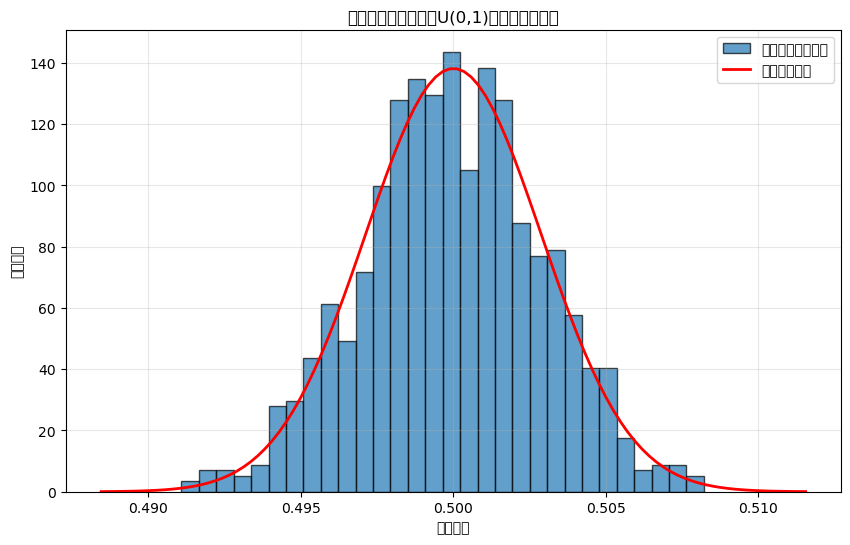

样本均值的实际方差: 0.000009
理论方差: 0.000008


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# 参数设置
n = 10000  # 每次抽样的样本量
m = 1000   # 重复次数

# 1. 生成m次样本，每次n个U(0,1)随机变量，计算每次的均值
sample_means = np.zeros(m)
for i in range(m):
    sample = np.random.uniform(0, 1, n)
    sample_means[i] = np.mean(sample)

# 2. 绘制直方图并叠加理论正态分布曲线
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, density=True, alpha=0.7, edgecolor='black', label='样本均值的直方图')

# 理论正态分布：均值为0.5，方差为(1/12)/n
mu = 0.5
sigma = np.sqrt((1/12) / n)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
plt.plot(x, norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理验证:U(0,1)样本均值的分布')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 3. 计算这些均值的实际方差
actual_var = np.var(sample_means, ddof=0)  # 总体方差
print(f'样本均值的实际方差: {actual_var:.6f}')
print(f'理论方差: {((1/12)/n):.6f}')

### 4.1 理论计算题
1. 先令 u = w1 x1 + w2 x2 - y，则 z = u^2

   ∂z/∂w1 = 2u × ∂u/∂w1 = 2(w1 x1 + w2 x2 - y) × x1
          = 2x1 (w1 x1 + w2 x2 - y)

   ∂z/∂w2 = 2u × ∂u/∂w2 = 2(w1 x1 + w2 x2 - y) × x2
          = 2x2 (w1 x1 + w2 x2 - y)

   代入 x1 = 2, x2 = 1, y = 3：

   ∂z/∂w1 = 2×2×(2w1 + 1×w2 - 3) = 4(2w1 + w2 - 3)

   ∂z/∂w2 = 2×1×(2w1 + w2 - 3) = 2(2w1 + w2 - 3)

2. 当 w1 = 0.5, w2 = 1 时：

   2w1 + w2 - 3 = 2×0.5 + 1 - 3 = 1 + 1 - 3 = -1

   ∂z/∂w1 = 4 × (-1) = -4
   ∂z/∂w2 = 2 × (-1) = -2

   梯度为 (∂z/∂w1, ∂z/∂w2) = (-4, -2)

In [7]:
import torch

# 手动实现前向计算和梯度
x = 2.0
w1 = 1.5
w2 = 0.5

# 前向计算
a = x * w1
b = a + w2
L = b ** 2

# 手动求梯度（链式法则）
# dL/db = 2b
dL_db = 2 * b
# db/da = 1
# da/dw1 = x
dL_dw1_manual = dL_db * 1 * x
# db/dw2 = 1
dL_dw2_manual = dL_db * 1

print("前向结果：")
print(f"a = {a}, b = {b}, L = {L}")
print(f"\n手动计算的梯度：")
print(f"dL/dw1 = {dL_dw1_manual}")
print(f"dL/dw2 = {dL_dw2_manual}")

# 用 PyTorch 验证
x_t = torch.tensor(2.0, requires_grad=False)
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)

a_t = x_t * w1_t
b_t = a_t + w2_t
L_t = b_t ** 2

L_t.backward()

print(f"\n自动微分结果：")
print(f"dL/dw1 = {w1_t.grad.item()}")
print(f"dL/dw2 = {w2_t.grad.item()}")

# 验证是否一致
print(f"\n手动与自动微分是否一致：")
print(f"w1: {abs(dL_dw1_manual - w1_t.grad.item()) < 1e-6}")
print(f"w2: {abs(dL_dw2_manual - w2_t.grad.item()) < 1e-6}")

前向结果：
a = 3.0, b = 3.5, L = 12.25

手动计算的梯度：
dL/dw1 = 14.0
dL/dw2 = 7.0

自动微分结果：
dL/dw1 = 14.0
dL/dw2 = 7.0

手动与自动微分是否一致：
w1: True
w2: True


### 5.1 理论计算题
令残差 di = yi - (wxi + b)，则 L = (1/n) * Σ di^2

先求 ∂L/∂b：

∂L/∂b = (1/n) * Σ 2(yi - wxi - b) * (-1)
      = -(2/n) * Σ (yi - wxi - b)

再求 ∂L/∂w：

∂L/∂w = (1/n) * Σ 2(yi - wxi - b) * (-xi)
      = -(2/n) * Σ (yi - wxi - b) * xi

In [5]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# 加载数据
digits = load_digits()
X = digits.data  # (1797, 64)
y = digits.target.reshape(-1, 1)  # (1797, 1)

# 归一化
X = X / 16.0

# one-hot编码
encoder = OneHotEncoder(sparse_output=False)
y_onehot = encoder.fit_transform(y)

# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(X, y_onehot, test_size=0.2, random_state=42)

# 参数初始化
input_size = X_train.shape[1]  # 64
num_classes = y_train.shape[1]  # 10
W = np.random.randn(input_size, num_classes) * 0.01
b = np.zeros((1, num_classes))

# softmax函数
def softmax(z):
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# 交叉熵损失
def cross_entropy_loss(y_pred, y_true):
    n = y_pred.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

# 训练参数
epochs = 50
batch_size = 32
lr = 0.1
n_samples = X_train.shape[0]

# 训练
for epoch in range(epochs):
    # 打乱数据
    indices = np.random.permutation(n_samples)
    X_shuffled = X_train[indices]
    y_shuffled = y_train[indices]
    
    total_loss = 0
    
    # 小批量梯度下降
    for i in range(0, n_samples, batch_size):
        X_batch = X_shuffled[i:i+batch_size]
        y_batch = y_shuffled[i:i+batch_size]
        
        # 前向传播
        logits = np.dot(X_batch, W) + b
        y_pred = softmax(logits)
        
        # 计算损失
        loss = cross_entropy_loss(y_pred, y_batch)
        total_loss += loss
        
        # 反向传播
        grad_logits = y_pred - y_batch
        grad_W = np.dot(X_batch.T, grad_logits) / batch_size
        grad_b = np.sum(grad_logits, axis=0, keepdims=True) / batch_size
        
        # 更新参数
        W -= lr * grad_W
        b -= lr * grad_b
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / (n_samples/batch_size):.4f}")

# 测试
logits_test = np.dot(X_test, W) + b
y_pred_test = softmax(logits_test)
y_pred_labels = np.argmax(y_pred_test, axis=1)
y_true_labels = np.argmax(y_test, axis=1)

accuracy = np.mean(y_pred_labels == y_true_labels)
print(f"\n测试集准确率: {accuracy * 100:.2f}%")

Epoch 10/50, Loss: 0.4583
Epoch 20/50, Loss: 0.3014
Epoch 30/50, Loss: 0.2416
Epoch 40/50, Loss: 0.2088
Epoch 50/50, Loss: 0.1862

测试集准确率: 96.11%


### 6.1 理论计算题
1. 正态分布的概率密度函数为

   f(xi; μ, σ²) = (1 / √(2πσ²)) exp[ -(xi - μ)² / (2σ²) ]

   由于样本独立，似然函数为

   L(μ, σ²) = ∏ f(xi; μ, σ²)
            = (2πσ²)^(-n/2) exp[ -Σ(xi - μ)² / (2σ²) ]

   对数似然函数为

   ln L = - (n/2) ln(2π) - (n/2) ln(σ²) - Σ(xi - μ)² / (2σ²)

2. 对 μ 求偏导并令为 0：

   ∂(ln L)/∂μ = - (1/σ²) Σ(xi - μ) = 0

   得到 Σ(xi - μ) = 0，即 Σxi - nμ = 0

   所以 μ̂ = (1/n) Σ xi

3. 令 τ = σ²，对 τ 求偏导：

   ∂(ln L)/∂τ = - n/(2τ) + Σ(xi - μ)² / (2τ²) = 0

   两边乘以 2τ²得： - nτ + Σ(xi - μ)² = 0

   所以 τ̂ = (1/n) Σ (xi - μ)²

   将 μ 替换为 μ̂ 得：

   σ̂² = (1/n) Σ (xi - μ̂)²

Iteration 200, Loss: 0.3283
Iteration 400, Loss: 0.3197
Iteration 600, Loss: 0.3155
Iteration 800, Loss: 0.3129
Iteration 1000, Loss: 0.3111


d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36923 (\N{CJK UNIFIED IDEOGRAPH-903B}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 36753 (\N{CJK UNIFIED IDEOGRAPH-8F91}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 24402 (\N{CJK UNIFIED IDEOGRAPH-5F52}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20915 (\N{CJK UNIFIED IDEOGRAPH-51B3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.p

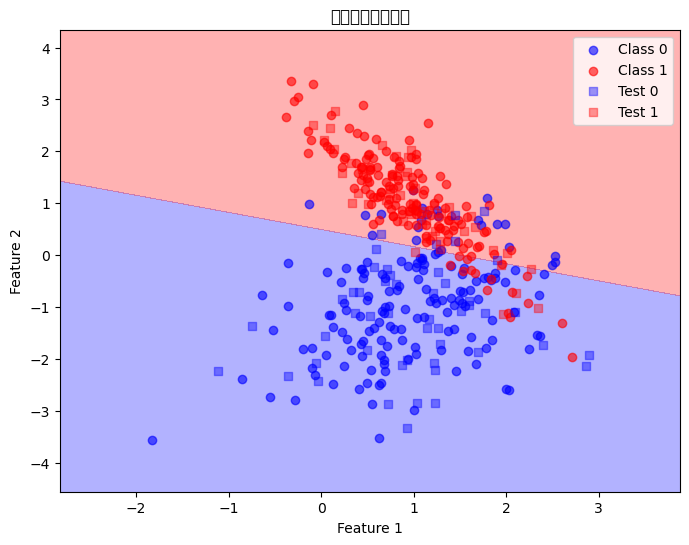


测试集准确率: 88.00%


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

# 设置随机种子
np.random.seed(42)

# 1. 生成两类线性可分的数据
X, y = make_classification(n_samples=400, n_features=2, n_redundant=0, n_informative=2,
                           n_clusters_per_class=1, n_classes=2, random_state=42)
y = y.reshape(-1, 1)  # 变成列向量

# 划分训练集和测试集
X_train, X_test = X[:300], X[300:]
y_train, y_test = y[:300], y[300:]

# 2. 定义sigmoid函数和二元交叉熵损失
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_pred, y_true):
    eps = 1e-8
    return -np.mean(y_true * np.log(y_pred + eps) + (1 - y_true) * np.log(1 - y_pred + eps))

# 初始化参数
w = np.random.randn(2, 1) * 0.01
b = 0.0

# 3. 梯度下降训练
lr = 0.1
iterations = 1000
losses = []

for i in range(iterations):
    # 前向传播
    z = np.dot(X_train, w) + b
    y_pred = sigmoid(z)
    
    # 计算损失
    loss = binary_cross_entropy(y_pred, y_train)
    losses.append(loss)
    
    # 反向传播（梯度计算）
    dz = y_pred - y_train
    dw = np.dot(X_train.T, dz) / len(y_train)
    db = np.mean(dz)
    
    # 更新参数
    w -= lr * dw
    b -= lr * db
    
    if (i+1) % 200 == 0:
        print(f"Iteration {i+1}, Loss: {loss:.4f}")

# 4. 绘制决策边界
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))
Z = sigmoid(np.dot(np.c_[xx.ravel(), yy.ravel()], w) + b)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, levels=[0, 0.5, 1], alpha=0.3, colors=['blue', 'red'])
plt.scatter(X_train[y_train.flatten()==0, 0], X_train[y_train.flatten()==0, 1], c='blue', label='Class 0', alpha=0.6)
plt.scatter(X_train[y_train.flatten()==1, 0], X_train[y_train.flatten()==1, 1], c='red', label='Class 1', alpha=0.6)
plt.scatter(X_test[y_test.flatten()==0, 0], X_test[y_test.flatten()==0, 1], c='blue', marker='s', alpha=0.4, label='Test 0')
plt.scatter(X_test[y_test.flatten()==1, 0], X_test[y_test.flatten()==1, 1], c='red', marker='s', alpha=0.4, label='Test 1')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('逻辑回归决策边界')
plt.legend()
plt.show()

# 计算测试集准确率
y_pred_test = sigmoid(np.dot(X_test, w) + b)
y_pred_labels = (y_pred_test >= 0.5).astype(int)
accuracy = np.mean(y_pred_labels == y_test)
print(f"\n测试集准确率: {accuracy * 100:.2f}%")